=== FOLDER STRUCTURE ===
RealSynthX/
  AI Generated Images/
    9123 (2).jpg
    9115 (2).jpg
    34Gm48WEtbvNz9z8PYZX.png
    ... (1910 files total)
  Real Scene Images/
    623.jpg
    image745.png
    image883.png
    ... (1910 files total)

Total images found: 3820

=== CLASS BALANCE ===
class
AI_Generated    1910
Real_Scene      1910
Name: count, dtype: int64


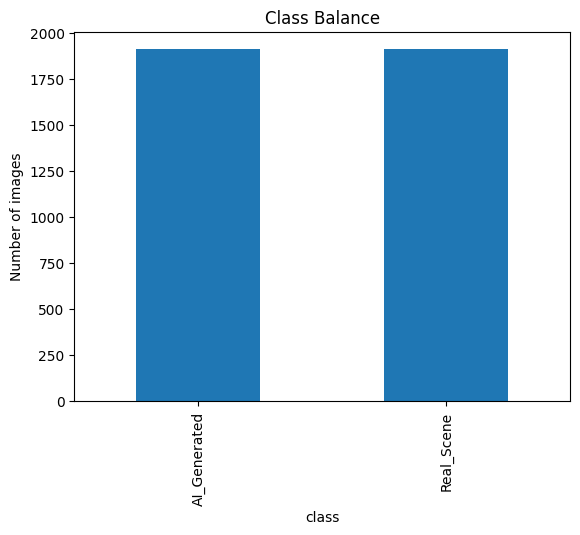


=== FILE FORMAT DISTRIBUTION ===
extension
.png     2327
.jpg     1475
.jpeg      15
.webp       3
Name: count, dtype: int64

=== IMAGE DIMENSIONS ===
             width       height
count  3820.000000  3820.000000
mean   1006.511780   952.506545
std     990.962334  1127.224852
min     154.000000   159.000000
25%     560.000000   425.000000
50%     652.000000   525.000000
75%    1024.000000  1024.000000
max    8192.000000  8192.000000

Unique resolutions found: 1064
Most common resolutions:
width  height
560    425       833
1024   1024      779
525    525       137
896    1344      127
928    1232       98
570    570        91
960    1200       83
1456   816        79
816    1456       59
4000   6000       36
dtype: int64

=== COLOR MODE DISTRIBUTION ===
mode
RGB     2991
RGBA     825
P          4
Name: count, dtype: int64

=== CORRUPT / UNREADABLE FILES ===
Count: 0


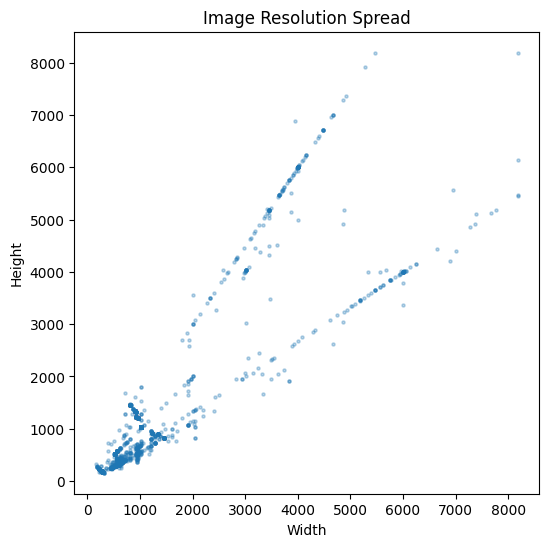


=== SUMMARY ===
Total valid images: 3820
Corrupt/unreadable: 0
Formats present: ['.jpg', '.png', '.webp', '.jpeg']
Resolution range: 154x159 to 8192x8192
Color modes present: ['RGB', 'RGBA', 'P']
Class counts: {'AI_Generated': np.int64(1910), 'Real_Scene': np.int64(1910)}


In [1]:
#cell 1
import os
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. SET YOUR DATASET ROOT PATH ----
DATASET_ROOT = "/kaggle/input/datasets/alifziad/realsynthx/RealSynthX/RealSynthX"

# ---- 2. EXPLORE FOLDER STRUCTURE ----
print("=== FOLDER STRUCTURE ===")
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... ({len(files)} files total)")

# ---- 3. COLLECT ALL IMAGE PATHS PER CLASS ----
class_folders = {
    "AI_Generated": os.path.join(DATASET_ROOT, "AI Generated Images"),
    "Real_Scene": os.path.join(DATASET_ROOT, "Real Scene Images"),
}

image_data = []
for label, folder in class_folders.items():
    if not os.path.exists(folder):
        print(f"WARNING: path not found -> {folder}")
        continue
    for f in os.listdir(folder):
        image_data.append({"filename": f, "class": label, "path": os.path.join(folder, f)})

df = pd.DataFrame(image_data)
print(f"\nTotal images found: {len(df)}")

# ---- 4. CLASS BALANCE CHECK ----
print("\n=== CLASS BALANCE ===")
print(df["class"].value_counts())

df["class"].value_counts().plot(kind="bar", title="Class Balance")
plt.ylabel("Number of images")
plt.show()

# ---- 5. FORMAT CONSISTENCY CHECK ----
df["extension"] = df["filename"].apply(lambda x: Path(x).suffix.lower())
print("\n=== FILE FORMAT DISTRIBUTION ===")
print(df["extension"].value_counts())

# ---- 6. RESOLUTION / MODE / CORRUPT FILE CHECK ----
widths, heights, modes, corrupt_files = [], [], [], []

for path in df["path"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception as e:
        corrupt_files.append((path, str(e)))

df_valid = df.iloc[:len(widths)].copy()
df_valid["width"] = widths
df_valid["height"] = heights
df_valid["mode"] = modes

print(f"\n=== IMAGE DIMENSIONS ===")
print(df_valid[["width", "height"]].describe())

print(f"\nUnique resolutions found: {df_valid[['width','height']].drop_duplicates().shape[0]}")
print(f"Most common resolutions:")
print(df_valid.groupby(["width","height"]).size().sort_values(ascending=False).head(10))

print(f"\n=== COLOR MODE DISTRIBUTION ===")
print(df_valid["mode"].value_counts())

print(f"\n=== CORRUPT / UNREADABLE FILES ===")
print(f"Count: {len(corrupt_files)}")
for path, err in corrupt_files[:10]:
    print(f" - {path}: {err}")

# ---- 7. RESOLUTION SCATTER PLOT ----
plt.figure(figsize=(6,6))
plt.scatter(df_valid["width"], df_valid["height"], alpha=0.3, s=5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Spread")
plt.show()

# ---- 8. SUMMARY ----
print("\n=== SUMMARY ===")
print(f"Total valid images: {len(df_valid)}")
print(f"Corrupt/unreadable: {len(corrupt_files)}")
print(f"Formats present: {df['extension'].unique().tolist()}")
print(f"Resolution range: {df_valid['width'].min()}x{df_valid['height'].min()} to {df_valid['width'].max()}x{df_valid['height'].max()}")
print(f"Color modes present: {df_valid['mode'].unique().tolist()}")
print(f"Class counts: {dict(df['class'].value_counts())}")

In [2]:
#cell 2
import os
import shutil
from pathlib import Path
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ---- CONFIG ----
DATASET_ROOT = "/kaggle/input/datasets/alifziad/realsynthx/RealSynthX/RealSynthX"
OUTPUT_ROOT = "/kaggle/working/RealSynthX_processed"
IMG_SIZE = (224, 224)   # change to (256,256) if your model needs it
RANDOM_SEED = 42

class_folders = {
    "AI_Generated": os.path.join(DATASET_ROOT, "AI Generated Images"),
    "Real_Scene": os.path.join(DATASET_ROOT, "Real Scene Images"),
}

# ---- 1. BUILD FILE LIST ----
image_data = []
for label, folder in class_folders.items():
    for f in os.listdir(folder):
        image_data.append({"filename": f, "class": label, "path": os.path.join(folder, f)})

df = pd.DataFrame(image_data).reset_index(drop=True)
print(f"Total images found: {len(df)}")
print(df["class"].value_counts())

# ---- CHECK FOR FILENAME STEM COLLISIONS (diagnostic) ----
for label, folder in class_folders.items():
    stems = {}
    for f in os.listdir(folder):
        stem = Path(f).stem
        stems.setdefault(stem, []).append(f)
    collisions = {k: v for k, v in stems.items() if len(v) > 1}
    if collisions:
        print(f"\nWARNING: {len(collisions)} filename stem collisions in {label}:")
        for stem, files in list(collisions.items())[:10]:
            print(f"  {stem}: {files}")

# ---- 2. STRATIFIED 70/15/15 SPLIT ----
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class"], random_state=RANDOM_SEED
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain class balance:\n", train_df["class"].value_counts())
print("\nVal class balance:\n", val_df["class"].value_counts())
print("\nTest class balance:\n", test_df["class"].value_counts())

splits = {"train": train_df, "val": val_df, "test": test_df}

# ---- 3. CREATE OUTPUT FOLDER STRUCTURE ----
for split_name in splits:
    for class_name in class_folders:
        os.makedirs(os.path.join(OUTPUT_ROOT, split_name, class_name), exist_ok=True)

# ---- 4. PREPROCESS + SAVE EACH IMAGE ----
def preprocess_and_save(row, split_name):
    src_path = row["path"]
    class_name = row["class"]
    # FIX: use class name + original row index to guarantee a unique filename,
    # preventing silent overwrites when two source files share the same stem
    # (e.g. "12.jpg" and "12.png" both existing in the same class folder).
    filename = f"{class_name}_{row.name}_{Path(row['filename']).stem}.jpg"
    dst_path = os.path.join(OUTPUT_ROOT, split_name, class_name, filename)

    try:
        with Image.open(src_path) as img:
            img = img.convert("RGB")          # fixes RGBA / palette mode issues
            img = img.resize(IMG_SIZE, Image.LANCZOS)  # fixes resolution inconsistency
            img.save(dst_path, "JPEG", quality=95)      # standardizes format
        return True
    except Exception as e:
        print(f"Failed: {src_path} -> {e}")
        return False

print("\n=== PROCESSING TRAIN SET ===")
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    preprocess_and_save(row, "train")

print("\n=== PROCESSING VAL SET ===")
for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    preprocess_and_save(row, "val")

print("\n=== PROCESSING TEST SET ===")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    preprocess_and_save(row, "test")

# ---- 5. VERIFY OUTPUT ----
print("\n=== FINAL OUTPUT VERIFICATION ===")
total_output = 0
for split_name in splits:
    for class_name in class_folders:
        folder = os.path.join(OUTPUT_ROOT, split_name, class_name)
        count = len(os.listdir(folder))
        total_output += count
        print(f"{split_name}/{class_name}: {count} images")

print(f"\nTotal output images: {total_output} (expected: {len(df)})")
if total_output == len(df):
    print("✅ No images lost during processing.")
else:
    print(f"⚠️ {len(df) - total_output} images missing — check for errors above.")

print(f"\nDone. Processed dataset saved to: {OUTPUT_ROOT}")

Total images found: 3820
class
AI_Generated    1910
Real_Scene      1910
Name: count, dtype: int64

  Image_6: ['Image_6.png', 'Image_6.jpg']
  5: ['5.jpg', '5.png']
  Image_13: ['Image_13.png', 'Image_13.jpg']
  Image_19: ['Image_19.jpg', 'Image_19.png']

Train: 2674 | Val: 573 | Test: 573

Train class balance:
 class
Real_Scene      1337
AI_Generated    1337
Name: count, dtype: int64

Val class balance:
 class
Real_Scene      287
AI_Generated    286
Name: count, dtype: int64

Test class balance:
 class
AI_Generated    287
Real_Scene      286
Name: count, dtype: int64

=== PROCESSING TRAIN SET ===


100%|██████████| 2674/2674 [03:10<00:00, 14.06it/s]



=== PROCESSING VAL SET ===


100%|██████████| 573/573 [00:42<00:00, 13.60it/s]



=== PROCESSING TEST SET ===


100%|██████████| 573/573 [00:39<00:00, 14.35it/s]


=== FINAL OUTPUT VERIFICATION ===
train/AI_Generated: 1337 images
train/Real_Scene: 1337 images
val/AI_Generated: 286 images
val/Real_Scene: 287 images
test/AI_Generated: 287 images
test/Real_Scene: 286 images

Total output images: 3820 (expected: 3820)
✅ No images lost during processing.

Done. Processed dataset saved to: /kaggle/working/RealSynthX_processed


In [3]:
#cell 3
import os
from pathlib import Path
from PIL import Image
import pandas as pd

DATASET_ROOT = "/kaggle/input/datasets/alifziad/realsynthx/RealSynthX/RealSynthX"
OUTPUT_ROOT = "/kaggle/working/RealSynthX_processed"

class_folders = {
    "AI_Generated": os.path.join(DATASET_ROOT, "AI Generated Images"),
    "Real_Scene": os.path.join(DATASET_ROOT, "Real Scene Images"),
}

# ---- 0. GET EXPECTED COUNTS FROM SOURCE ----
expected_counts = {}
for label, folder in class_folders.items():
    expected_counts[label] = len(os.listdir(folder))
expected_total = sum(expected_counts.values())
print("=== EXPECTED COUNTS (from source folders) ===")
for label, count in expected_counts.items():
    print(f"{label}: {count}")
print(f"Total expected: {expected_total}")

# ---- 1. TOTAL FOLDER SIZE ----
def get_folder_size(path):
    total = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return total

total_bytes = get_folder_size(OUTPUT_ROOT)
print("\n=== FINAL DATASET SIZE ===")
print(f"Total size: {total_bytes / (1024**2):.2f} MB  ({total_bytes / (1024**3):.3f} GB)")

# ---- 2. SIZE + COUNT BREAKDOWN PER SPLIT / CLASS ----
print("\n=== SIZE BREAKDOWN ===")
rows = []
for split_name in ["train", "val", "test"]:
    for class_name in ["AI_Generated", "Real_Scene"]:
        folder = os.path.join(OUTPUT_ROOT, split_name, class_name)
        if not os.path.exists(folder):
            continue
        size = get_folder_size(folder)
        count = len(os.listdir(folder))
        rows.append({
            "split": split_name,
            "class": class_name,
            "count": count,
            "size_MB": round(size / (1024**2), 2)
        })

size_df = pd.DataFrame(rows)
print(size_df)
print(f"\nAverage size per image: {total_bytes / size_df['count'].sum() / 1024:.1f} KB")

# ---- 3. RE-VERIFY ATTRIBUTES ON PROCESSED IMAGES ----
image_data = []
for split_name in ["train", "val", "test"]:
    for class_name in ["AI_Generated", "Real_Scene"]:
        folder = os.path.join(OUTPUT_ROOT, split_name, class_name)
        if not os.path.exists(folder):
            continue
        for f in os.listdir(folder):
            image_data.append({
                "filename": f,
                "split": split_name,
                "class": class_name,
                "path": os.path.join(folder, f)
            })

proc_df = pd.DataFrame(image_data)
print(f"\nTotal processed images: {len(proc_df)}")

# Extension check
proc_df["extension"] = proc_df["filename"].apply(lambda x: Path(x).suffix.lower())
print("\n=== FORMAT CHECK (should be uniform now) ===")
print(proc_df["extension"].value_counts())

# Resolution + mode check
widths, heights, modes, corrupt = [], [], [], []
for path in proc_df["path"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception as e:
        corrupt.append((path, str(e)))

proc_df_valid = proc_df.iloc[:len(widths)].copy()
proc_df_valid["width"] = widths
proc_df_valid["height"] = heights
proc_df_valid["mode"] = modes

print("\n=== RESOLUTION CHECK (should be uniform now) ===")
print(proc_df_valid[["width", "height"]].describe())
print(f"\nUnique resolutions: {proc_df_valid[['width','height']].drop_duplicates().shape[0]}")

print("\n=== COLOR MODE CHECK (should be all RGB now) ===")
print(proc_df_valid["mode"].value_counts())

print(f"\n=== CORRUPT FILES ===")
print(f"Count: {len(corrupt)}")

# ---- 4. FINAL CLASS + SPLIT BALANCE ----
print("\n=== FINAL SPLIT / CLASS COUNTS ===")
print(proc_df.groupby(["split", "class"]).size())

# ---- 5. AUTOMATED MISMATCH CHECK ----
print("\n=== INTEGRITY CHECK: PROCESSED vs SOURCE ===")
actual_per_class = proc_df.groupby("class").size().to_dict()
all_ok = True
for label, expected in expected_counts.items():
    actual = actual_per_class.get(label, 0)
    status = "✅" if actual == expected else "❌"
    if actual != expected:
        all_ok = False
    print(f"{status} {label}: expected {expected}, got {actual} (missing: {expected - actual})")

print(f"\nTotal: expected {expected_total}, got {len(proc_df)}")
if all_ok and len(proc_df) == expected_total:
    print("✅ All images accounted for — dataset is complete.")
else:
    print(f"⚠️ {expected_total - len(proc_df)} image(s) missing. "
          f"Likely cause: filename collisions during preprocessing, "
          f"or OUTPUT_ROOT wasn't cleared before re-running.")

# ---- 6. SUMMARY ----
print("\n=== FINAL SUMMARY ===")
print(f"Total images: {len(proc_df)}")
print(f"Total size: {total_bytes / (1024**2):.2f} MB")
print(f"Formats present: {proc_df['extension'].unique().tolist()}")
print(f"Resolution: {proc_df_valid['width'].unique().tolist() if proc_df_valid['width'].nunique()==1 else 'NOT uniform'} x {proc_df_valid['height'].unique().tolist() if proc_df_valid['height'].nunique()==1 else 'NOT uniform'}")
print(f"Color modes: {proc_df_valid['mode'].unique().tolist()}")

=== EXPECTED COUNTS (from source folders) ===
AI_Generated: 1910
Real_Scene: 1910
Total expected: 3820

=== FINAL DATASET SIZE ===
Total size: 84.87 MB  (0.083 GB)

=== SIZE BREAKDOWN ===
   split         class  count  size_MB
0  train  AI_Generated   1337    29.21
1  train    Real_Scene   1337    29.94
2    val  AI_Generated    286     6.31
3    val    Real_Scene    287     6.41
4   test  AI_Generated    287     6.34
5   test    Real_Scene    286     6.67

Average size per image: 22.8 KB

Total processed images: 3820

=== FORMAT CHECK (should be uniform now) ===
extension
.jpg    3820
Name: count, dtype: int64

=== RESOLUTION CHECK (should be uniform now) ===
        width  height
count  3820.0  3820.0
mean    224.0   224.0
std       0.0     0.0
min     224.0   224.0
25%     224.0   224.0
50%     224.0   224.0
75%     224.0   224.0
max     224.0   224.0

Unique resolutions: 1

=== COLOR MODE CHECK (should be all RGB now) ===
mode
RGB    3820
Name: count, dtype: int64

=== CORRUPT FILE